## Compare Distributions

In [29]:
# imports and configurations
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os


work_dir = "/jumbo/keller-lab/Jeremy_Wang/eplus_sa/scripts/main" # Change this to your working directory

In [5]:
# Load the data
for seed in range(1, 6):
    seed_name = f"seed_{seed}"
    normal_indices = pd.read_csv(
        f"{work_dir}/sobol_indices/{seed_name}/totalorder_indices.csv"
    )
    uniform_indices = pd.read_csv(
        f"{work_dir}/sobol_indices_uniform/{seed_name}/totalorder_indices.csv"
    )
    beta_indices = pd.read_csv(
        f"{work_dir}/sobol_indices_beta/{seed_name}/totalorder_indices.csv"
    )
    # append
    if seed == 1:
        all_normal_indices = normal_indices
        all_uniform_indices = uniform_indices
        all_beta_indices = beta_indices
    else:
        all_normal_indices = pd.concat([all_normal_indices, normal_indices], ignore_index=True)
        all_uniform_indices = pd.concat([all_uniform_indices, uniform_indices], ignore_index=True)
        all_beta_indices = pd.concat([all_beta_indices, beta_indices], ignore_index=True)

In [17]:
all_dfs = []

# Load all distributions + seeds
for seed in range(1, 6):

    seed_name = f"seed_{seed}"

    # -----------------------------
    # Normal
    # -----------------------------
    normal_df = pd.read_csv(
        f"{work_dir}/sobol_indices/{seed_name}/totalorder_indices.csv"
    )

    normal_df["distribution"] = "Normal"
    normal_df["seed"] = seed

    all_dfs.append(normal_df)

    # -----------------------------
    # Uniform
    # -----------------------------
    uniform_df = pd.read_csv(
        f"{work_dir}/sobol_indices_uniform/{seed_name}/totalorder_indices.csv"
    )

    uniform_df["distribution"] = "Uniform"
    uniform_df["seed"] = seed

    all_dfs.append(uniform_df)

    # -----------------------------
    # Beta
    # -----------------------------
    beta_df = pd.read_csv(
        f"{work_dir}/sobol_indices_beta/{seed_name}/totalorder_indices.csv"
    )

    beta_df["distribution"] = "Beta"
    beta_df["seed"] = seed

    all_dfs.append(beta_df)

# Combine everything
all_indices = pd.concat(all_dfs, ignore_index=True)

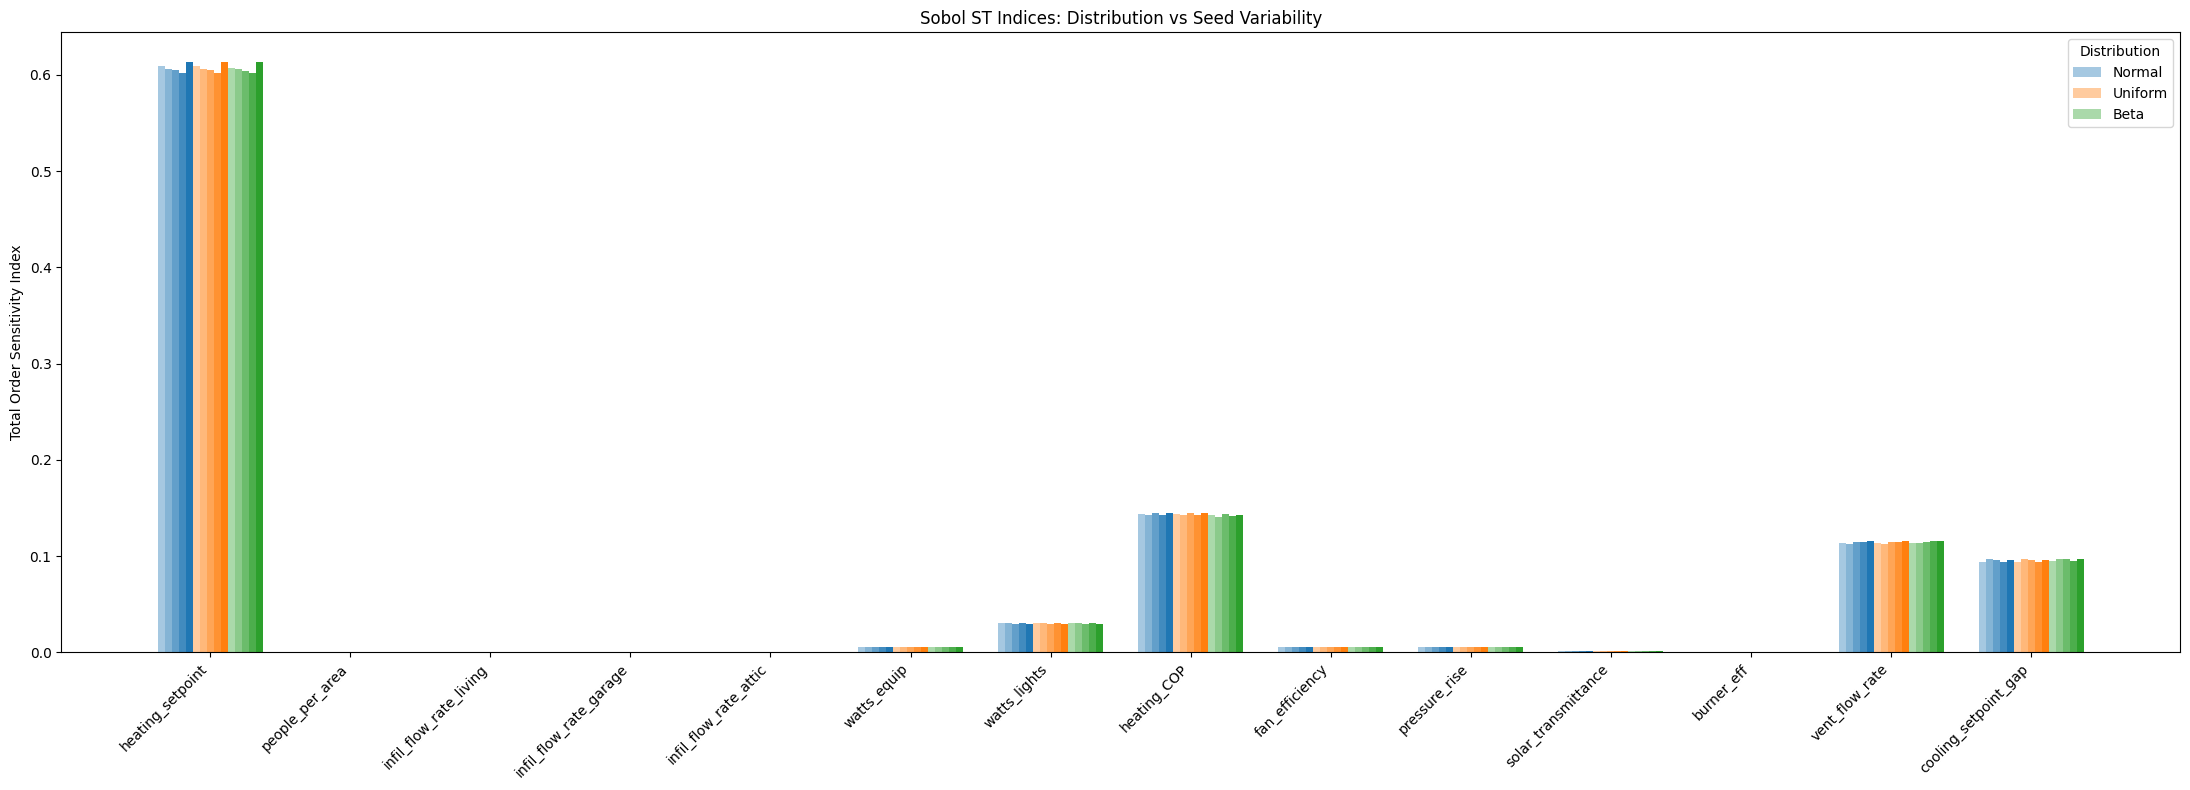

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure long format
plot_df = pd.melt(
    all_indices,
    id_vars=["distribution", "seed"],
    var_name="parameter",
    value_name="ST"
)

# Setup
params = plot_df["parameter"].unique()
distributions = ["Normal", "Uniform", "Beta"]
seeds = sorted(plot_df["seed"].unique())

colors = {
    "Normal": "tab:blue",
    "Uniform": "tab:orange",
    "Beta": "tab:green"
}

fig, ax = plt.subplots(figsize=(22, 8))

x = np.arange(len(params))

bar_width = 0.25
seed_offsets = np.linspace(-0.1, 0.1, len(seeds))
alphas = np.linspace(0.4, 1.0, len(seeds))  # low seed → transparent

# Loop over distributions
for i, dist in enumerate(distributions):

    for j, seed in enumerate(seeds):

        subset = plot_df[
            (plot_df["distribution"] == dist) &
            (plot_df["seed"] == seed)
        ]

        # Align values in correct parameter order
        values = [
            subset.loc[subset["parameter"] == p, "ST"].values[0]
            for p in params
        ]

        ax.bar(
            x + i * bar_width + seed_offsets[j],
            values,
            width=bar_width / len(seeds),
            color=colors[dist],
            alpha=alphas[j],
            label=dist if j == 0 else None
        )

# Formatting
ax.set_xticks(x + bar_width)
ax.set_xticklabels(params, rotation=45, ha="right")

ax.set_ylabel("Total Order Sensitivity Index")
ax.set_title("Sobol ST Indices: Distribution vs Seed Variability")

ax.legend(title="Distribution")
plt.tight_layout()
plt.show()

#### Sanity Check for Params

In [24]:
unif_params_seed1 = pd.read_csv(f"{work_dir}/params_uniform/simulation_parameters_seed_1.csv")
normal_params_seed1 = pd.read_csv(f"{work_dir}/params_sobol/simulation_parameters_seed_1.csv")

In [31]:
annual_consumption_normal = pd.read_pickle(os.path.join(work_dir, "analysis_sobol", "annual_consumption.pkl"))
annual_consumption_uniform = pd.read_pickle(os.path.join(work_dir, "analysis_uniform", "annual_consumption.pkl"))
annual_consumption_beta = pd.read_pickle(os.path.join(work_dir, "analysis_beta", "annual_consumption.pkl"))